In [64]:
#code to create unique occupied states plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec
from sklearn.metrics import roc_curve, auc

i = QCD
i = TTBar
[-19.11303711  -1.38461304 -10.99687195 ...   5.26385498  17.38800049
   1.56982422]
[0. 0. 0. ... 1. 1. 1.]
i = QCD
i = TTBar
[-13.55944824  -5.12077332  -9.2051239  ...  10.87020874   8.44670105
   3.94543457]
[0. 0. 0. ... 1. 1. 1.]


/tmp/ipykernel_84082/2031501430.py:56: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_84082/2031501430.py:67: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_84082/2031501430.py:56: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_84082/2031501430.py:67: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


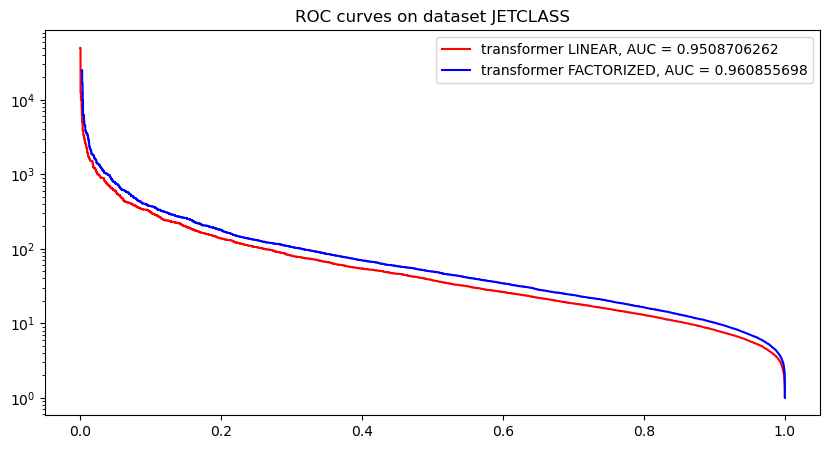

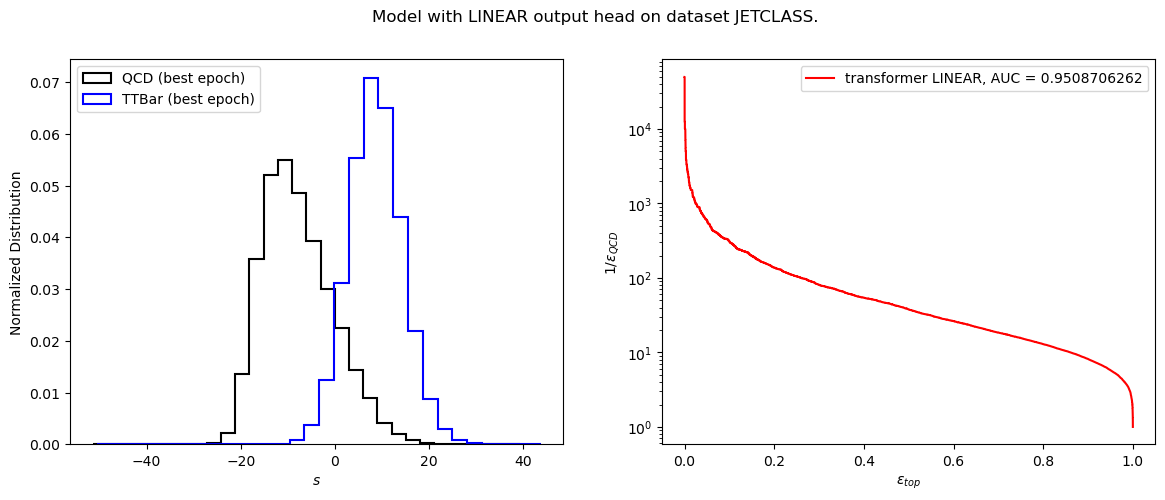

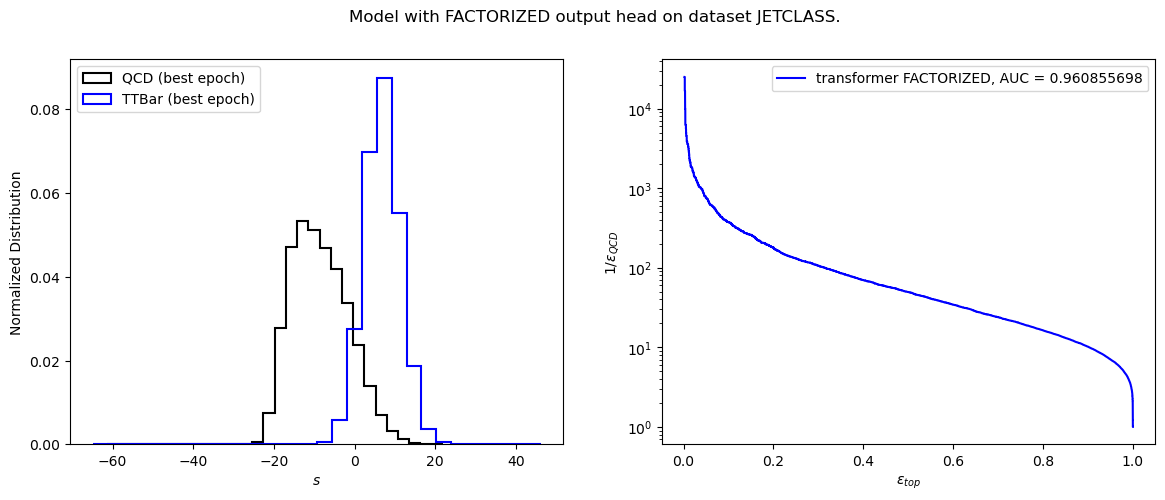

In [65]:
# creates s distributions
DATASET = "JETCLASS"
outputmodes = ["LINEAR", "FACTORIZED"]

classes = ["QCD", "TTBar"]
colors = ["black", "blue"]
colors_outputmodes = ["red", "blue"]

fid_roc, ax_roc = plt.subplots(figsize=(10, 5))

for j in range(len(outputmodes)):
        
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    bins = 60

    scores = np.array([])
    labels = np.array([])

    for i in range(len(classes)):
        top_vs_i = pd.read_csv(f"../output/plot_data_{DATASET.lower()}/probs_best_epoch/{classes[1]}_{outputmodes[j]}_{classes[i]}.csv")
        qcd_vs_i = pd.read_csv(f"../output/plot_data_{DATASET.lower()}/probs_best_epoch/{classes[0]}_{outputmodes[j]}_{classes[i]}.csv")

        s_i = top_vs_i - qcd_vs_i

        bins = 30

        # normalized histogram (area = 1), step style
        ax[0].hist(
            s_i["probs"],
            bins=bins,                 # adjust for smoothness
            density=True,            # normalization
            histtype="step",
            linewidth=1.5,
            linestyle="-",
            color=colors[i],
            label=f"{classes[i]} (best epoch)"
        )

        print(f"i = {classes[i]}")

        scores_i = s_i["probs"].to_numpy()

        #compute roc curve for each input mode and 
        scores = np.append(scores, scores_i)
        labels = np.append(labels, np.full(len(scores_i), i))


    print(scores)
    print(labels)

    fpr, tpr, thresholds = roc_curve(labels, scores)

    roc_auc = auc(fpr, tpr)

    ax[1].plot(tpr, 1/fpr, 
        color = colors_outputmodes[j],
        label = f"transformer {outputmodes[j]}, AUC = {roc_auc}")

    ax[1].set_yscale("log")

    ax[1].set_xlabel(r"$\epsilon_{top}$")
    ax[1].set_ylabel(r"$1/\epsilon_{QCD}$")

    ax[1].legend()

    ax_roc.plot(tpr, 1/fpr, 
                color = colors_outputmodes[j],
                label = f"transformer {outputmodes[j]}, AUC = {roc_auc}")

    fig.suptitle(f"Model with {outputmodes[j]} output head on dataset {DATASET}.")

    ax[0].set_ylabel("Normalized Distribution")
    ax[0].set_xlabel(r"$s$")

    #ax.set_xlim(-30, 30)

    ax[0].legend()

ax_roc.set_title(f"ROC curves on dataset {DATASET}")
ax_roc.legend()
ax_roc.set_yscale("log")

plt.show()
